### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_LSTM_P199 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, lstm, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

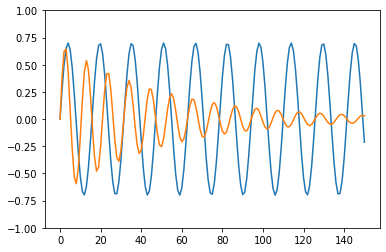

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 6

In [11]:
init_fun, qgru_rnn = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

199

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0006504466139070668   1.9406607151031494 sec      
199: 0.0004159372315131637   2.935239553451538 sec        
299: 0.00031374259288059276   3.88303542137146 sec        
399: 0.0002548475982666649   4.778316020965576 sec        
499: 0.00022401527575206947   5.6720898151397705 sec      
599: 0.00020297353741315208   6.563550710678101 sec       
699: 0.0001869056878387384   7.480834007263184 sec        
799: 0.00017361225160592388   8.454472541809082 sec       
899: 0.00016209557424097927   9.338205337524414 sec      
999: 0.00015131533941526085   10.256948471069336 sec      
1099: 0.00013845160132816537   11.122541904449463 sec      
1199: 0.0010383425948362781   12.02247142791748 sec        
1299: 0.00017237349703707748   12.927407264709473 sec      
1399: 0.0001481999177011855   14.024100065231323 sec       
learning rate: 0.1
1499: 0.0001756475261549802   14.990318298339844 sec       
1599: 0.00015482100878341814   15.992017269134521 sec      
1699: 0.0001328

26499: 3.650507441442504e-05   241.9587790966034 sec        
26599: 3.5510625366173136e-05   242.90156984329224 sec      
26699: 3.8300473948716105e-05   243.89940309524536 sec      
26799: 3.99798300002501e-05   244.8207688331604 sec         
26899: 3.603279694525032e-05   245.70851278305054 sec       
learning rate: 0.025
26999: 3.6817900099763546e-05   246.60314059257507 sec      
27099: 3.584753084734371e-05   247.53313183784485 sec       
27199: 3.5426513848241906e-05   248.4512209892273 sec       
27299: 3.516043399460523e-05   249.32189989089966 sec       
27399: 3.498008504623202e-05   250.20448994636536 sec       
27499: 3.4846268748777496e-05   251.13810229301453 sec      
learning rate: 0.2
27599: 0.000275503735563786   252.12051343917847 sec        
27699: 0.00023616762509721584   253.01398372650146 sec      
27799: 0.00021218974744683245   253.97154998779297 sec      
27899: 0.00018617891416990599   254.9429636001587 sec       
27999: 0.005219972210881134   255.85584044456

52599: 0.0001813661756134602   480.7853765487671 sec        
52699: 0.0001677439270449142   481.6576716899872 sec        
52799: 0.00014903252394757522   482.55830454826355 sec      
52899: 0.00012420432701582115   483.45265007019043 sec      
52999: 0.0002139623729834245   484.3956742286682 sec        
53099: 0.0001814917253901693   485.2992603778839 sec        
53199: 0.00016598647154786097   486.1788308620453 sec       
learning rate: 0.1
53299: 0.00022133325279901533   487.09070920944214 sec      
53399: 0.00018291259200541162   487.9983654022217 sec       
53499: 0.00015289227214559375   488.8839228153229 sec       
53599: 0.00012605552595346985   489.7528429031372 sec       
53699: 0.00010427822752685065   490.64720129966736 sec      
53799: 0.00010532407762322338   491.51785039901733 sec      
53899: 9.51085035493834e-05   492.4438900947571 sec         
53999: 0.004285766490012143   493.3523254394531 sec         
54099: 0.0003497991205213851   494.3012409210205 sec        
54199

79299: 0.00010512660052182836   732.4173595905304 sec      
79399: 0.00018990603677623217   733.3767771720886 sec      
79499: 9.322862060599534e-05   734.3453586101532 sec       
79599: 0.0009082078509957767   735.4045088291168 sec       
79699: 6.035180443172333e-05   736.3995313644409 sec       
79799: 5.6975411299542346e-05   737.3508944511414 sec      
79899: 7.108880664886032e-05   738.3067357540131 sec       
79999: 0.0001338589938791168   739.2841274738312 sec       
80099: 4.7682988841976274e-05   740.2551367282867 sec      
80199: 5.814697318450979e-05   741.1938738822937 sec       
80299: 7.0428092765438e-05   742.2194125652313 sec         
80399: 0.030515434461662806   743.1876263618469 sec        
learning rate: 0.1
80499: 0.0010818232481241434   744.083637714386 sec        
learning rate: 0.05
80599: 7.094401899926183e-05   745.002524137497 sec        
learning rate: 0.025
80699: 0.00024251817632677943   745.9380342960358 sec      
80799: 0.00010432957041174224   746.8808

105799: 9.35700799062648e-05   990.7289373874664 sec        
105899: 7.90272593313074e-05   991.8293504714966 sec       
105999: 7.730403206585669e-05   992.8431894779205 sec       
106099: 5.7442491432057466e-05   993.8546779155731 sec      
106199: 5.432772403206986e-05   994.8387093544006 sec       
106299: 4.866840590389731e-05   995.960813999176 sec        
106399: 4.682914086429632e-05   997.021475315094 sec        
106499: 4.2146096507989974e-05   998.0398116111755 sec      
106599: 4.185800952515227e-05   999.0362603664398 sec       
106699: 4.039574593182067e-05   1000.089910030365 sec       
106799: 4.051768702293088e-05   1001.1109480857849 sec       
106899: 3.9448514851227216e-05   1002.206577539444 sec       
106999: 4.643868099233205e-05   1003.2651340961456 sec       
107099: 3.879841004044573e-05   1004.2445199489594 sec       
107199: 6.0373009687123085e-05   1005.2436752319336 sec      
107299: 3.805119836824132e-05   1006.2538461685181 sec       
107399: 4.474037279

...

208799: 4.4158050184348166e-05   2054.949686050415 sec       
208899: 3.422196814550979e-05   2056.062731742859 sec        
208999: 3.50900764641974e-05   2057.089593887329 sec         
209099: 3.5803123087258616e-05   2058.095445871353 sec       
209199: 7.706425560965434e-05   2059.123621940613 sec        
learning rate: 0.025
209299: 3.544075675479991e-05   2060.232398748398 sec        
learning rate: 0.0125
209399: 3.4070432980317545e-05   2061.310820579529 sec       
209499: 3.387717873331613e-05   2062.403970718384 sec        
209599: 3.3776572210364164e-05   2063.589367866516 sec       
209699: 3.3702631234192836e-05   2064.646871805191 sec       
learning rate: 0.2
209799: 0.00022553156241347547   2065.8234343528748 sec      
209899: 0.00016176801816236496   2066.865010499954 sec       
209999: 0.00021306416291218166   2067.947293996811 sec       
210099: 0.0001738944384094112   2068.997997522354 sec        
210199: 0.00015293576892217285   2070.042136192322 sec       
210299: 

234399: 4.751860183305596e-05   2318.899598121643 sec        
234499: 6.52765335310874e-05   2319.887641429901 sec         
234599: 4.272601105759185e-05   2320.856197118759 sec        
234699: 6.476836516932368e-05   2321.8326983451843 sec       
234799: 5.792416599544445e-05   2322.8296842575073 sec       
234899: 5.425084912054535e-05   2323.785810947418 sec        
learning rate: 0.05
234999: 4.8652580309182124e-05   2324.742704629898 sec       
235099: 4.1713001791541266e-05   2325.7094507217407 sec      
235199: 3.9240230265525706e-05   2326.7090780735016 sec      
235299: 3.8518431270684285e-05   2327.7128047943115 sec      
235399: 3.947349808068724e-05   2328.683447599411 sec        
235499: 3.9214603952866255e-05   2329.6265676021576 sec      
235599: 3.655137273381466e-05   2330.610899925232 sec        
235699: 3.5762885378547876e-05   2331.554707288742 sec       
235799: 3.945684865191118e-05   2332.6034636497498 sec       
235899: 3.45919887386763e-05   2333.5622646808624 

259999: 5.828179704958689e-05   2553.1518080234528 sec       
260099: 5.458927327281735e-05   2554.0124225616455 sec       
260199: 6.446019785420351e-05   2554.8355536460876 sec       
260299: 5.2629575081578455e-05   2555.6544423103333 sec      
260399: 5.013971459714857e-05   2556.4894032478333 sec       
260499: 5.1159382894449e-05   2557.357208251953 sec          
260599: 4.832417379802379e-05   2558.2008118629456 sec       
260699: 4.891673904000556e-05   2559.0598397254944 sec       
260799: 4.588633251341161e-05   2559.9227035045624 sec       
260899: 4.4939067815164926e-05   2560.7530434131622 sec      
260999: 4.400527703341761e-05   2561.5768954753876 sec       
261099: 4.309624283172883e-05   2562.398074865341 sec        
261199: 4.1456306772674616e-05   2563.2549550533295 sec      
261299: 4.275452976684994e-05   2564.0934460163116 sec       
261399: 5.0269334638790835e-05   2564.90918135643 sec        
261499: 3.82450950615973e-05   2565.7332894802094 sec        
261599: 

285699: 0.00032969306784028313   2770.9981372356415 sec      
285799: 0.0001556457701846792   2771.8220937252045 sec       
learning rate: 0.1
285899: 0.0046237366903415   2772.6695477962494 sec         
285999: 0.0016249483687389623   2773.5339374542236 sec      
286099: 0.0007936393049386815   2774.3747384548187 sec      
learning rate: 0.05
286199: 0.0001444238295865824   2775.1878955364227 sec       
286299: 0.0001081799407153307   2776.004410982132 sec        
286399: 0.00010043850817521173   2776.8311240673065 sec      
286499: 9.504603669981625e-05   2777.67826294899 sec         
286599: 9.066968564969816e-05   2778.5158059597015 sec      
286699: 8.681076867739851e-05   2779.3587260246277 sec      
286799: 8.238810130917334e-05   2780.210696697235 sec       
286899: 9.688252242522774e-05   2781.038803577423 sec        
286999: 8.800972097735459e-05   2781.871108531952 sec       
287099: 8.289199654171193e-05   2782.7348403930664 sec      
learning rate: 0.025
287199: 9.15356851

311299: 9.894536402815938e-05   2987.230511903763 sec        
311399: 8.486429007519134e-05   2988.0608808994293 sec       
311499: 8.18386329908329e-05   2988.9315707683563 sec        
311599: 0.00011753909273067001   2989.7638947963715 sec      
311699: 5.0275218699811254e-05   2990.5825877189636 sec      
311799: 7.364718369108267e-05   2991.409408569336 sec        
311899: 3.974657958928669e-05   2992.231497526169 sec        
311999: 5.933579006571797e-05   2993.0921652317047 sec       
312099: 5.630613721047919e-05   2993.8970654010773 sec       
312199: 8.758659696149896e-05   2994.748487472534 sec        
learning rate: 0.025
312299: 5.0189197587240775e-05   2995.5656089782715 sec      
312399: 4.300331948491813e-05   2996.39697599411 sec         
312499: 3.905013957831237e-05   2997.2274656295776 sec       
312599: 3.7147064706216055e-05   2998.085219144821 sec       
312699: 3.6186403117112853e-05   2998.9167096614838 sec      
312799: 3.548982430082888e-05   2999.745560884475

In [23]:
minLoss

Array(3.30949956e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

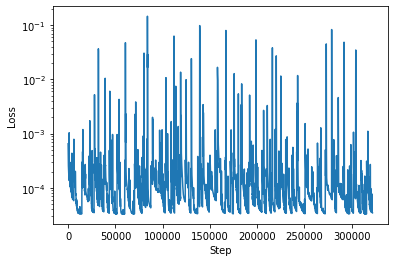

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

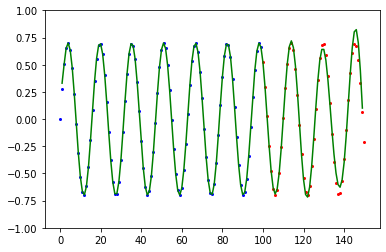

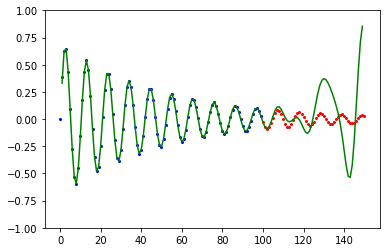

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

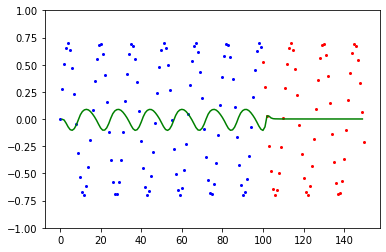

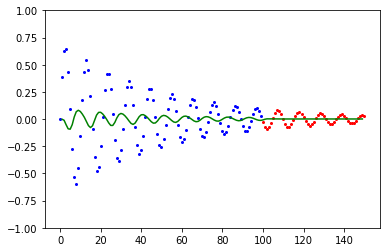

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[14600,
 Array(3.33566108e-05, dtype=float64),
 Array(0.00038379, dtype=float64),
 [(Array([[-0.43741636,  0.2798694 , -0.92996485,  0.40419455, -0.14513164,
           -0.56470357]], dtype=float64),
   Array([[-0.11137676,  0.27137605, -0.05940953, -0.56575596, -0.11649904,
            0.32289178],
          [ 0.43416329,  0.46313591, -0.48086889,  0.72142614,  0.13583981,
            0.70205576],
          [-0.44013887,  0.74030756,  0.1745629 ,  0.63595916, -0.03273827,
           -0.18189715],
          [-0.57483737, -0.17298285,  0.13253578,  0.65296389,  0.41635864,
            0.30538686],
          [-0.89867329,  0.2502819 ,  0.29535646, -0.2790064 ,  0.36923766,
            0.06274621],
          [ 0.04302986,  0.9119613 , -0.42069762,  0.28173142, -0.42342926,
            0.24146133]], dtype=float64),
   Array([ 0.01494811, -0.00688647, -0.01374036,  0.01206126, -0.01023333,
           0.01684677], dtype=float64),
   Array([[-3.06930317,  2.54385292, -1.13641897, -1.40118428,

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

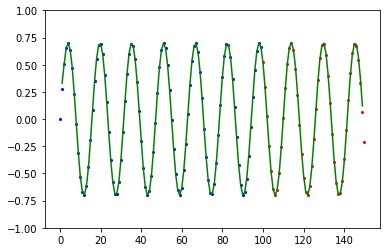

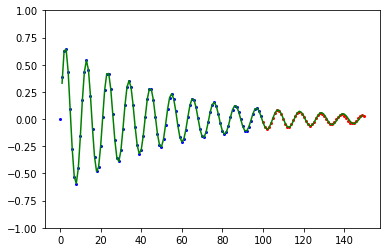

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [14600, Array(3.33566108e-05, dtype=float64), Array(0.00038379, dtype=float64)]
6100 5.810000491571042e-05 0.11698235384044381


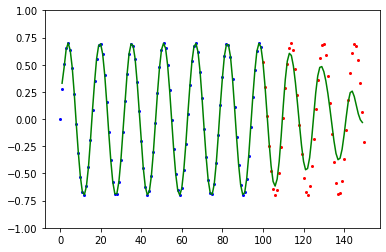

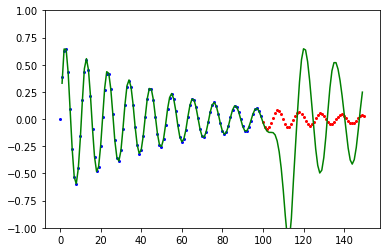

14600 3.3356610818527814e-05 0.00038378754279793016


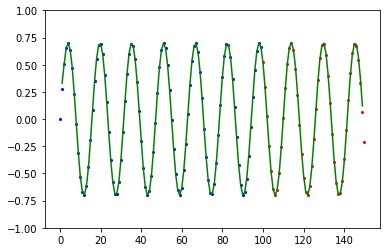

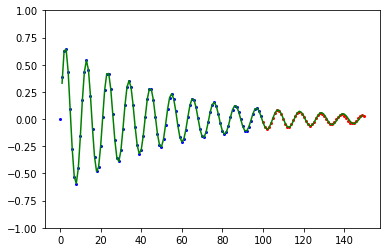

22100 5.7830844265618937e-05 0.5972734309782016


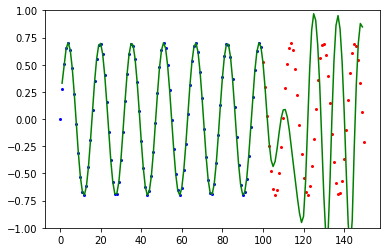

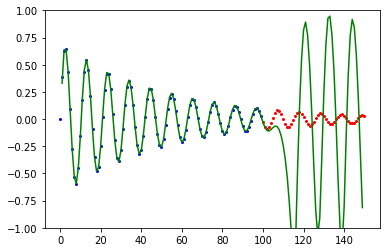

27500 3.4846268748777496e-05 0.13328368528111376


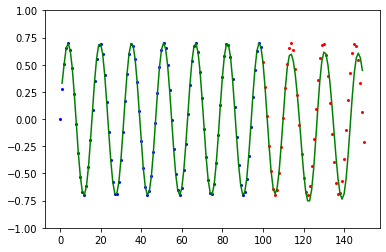

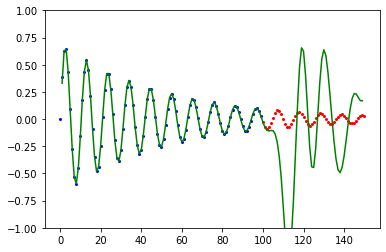

33400 4.5301395750829e-05 0.6513481402472726


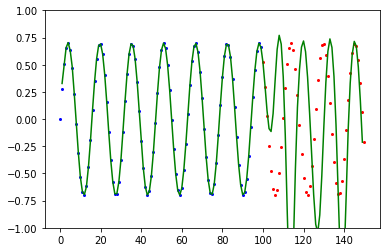

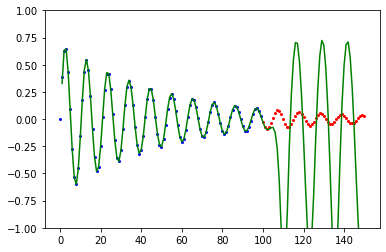

37800 3.6158502884493435e-05 0.7641997263339809


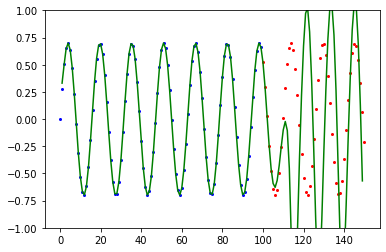

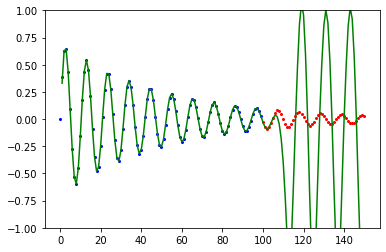

43600 3.401764927417929e-05 0.36071098676599234


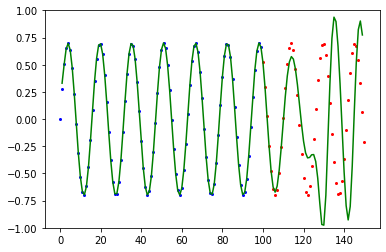

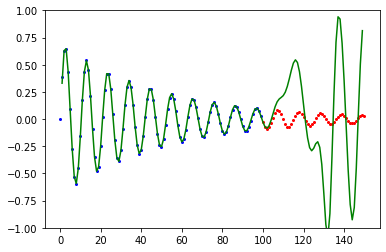

51800 3.3108386580383145e-05 0.005452446878041213


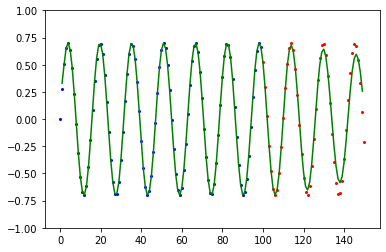

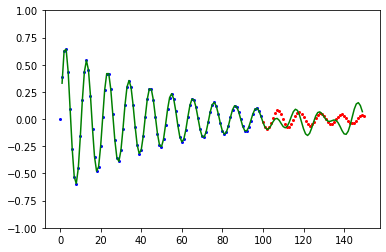

59900 3.309705820913402e-05 0.03411281538362063


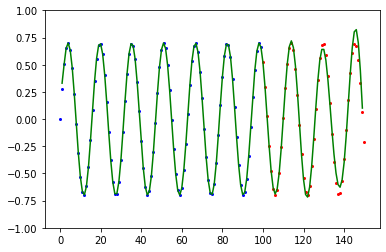

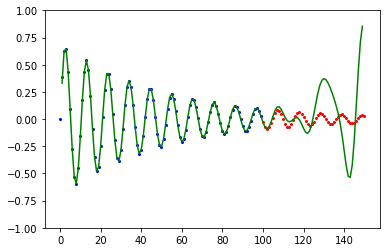

70300 3.328725978474963e-05 0.1919569753252436


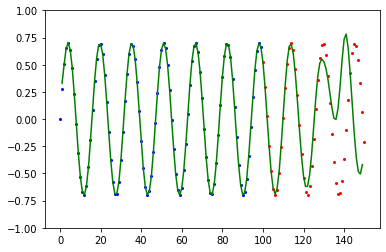

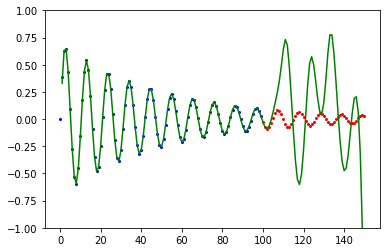

78200 3.386112123525502e-05 0.1553639591407045


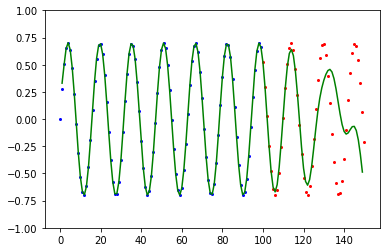

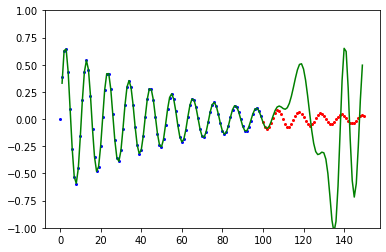

82100 4.361505375006275e-05 0.7815644356368929


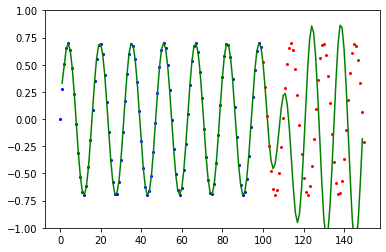

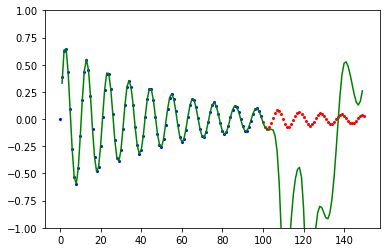

87500 4.2824894961006916e-05 0.5899319679354948


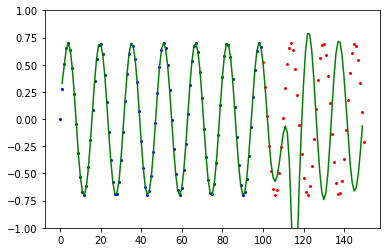

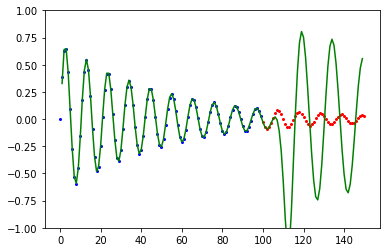

96300 8.258115968743526e-05 0.10400732242839639


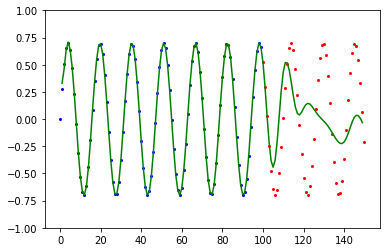

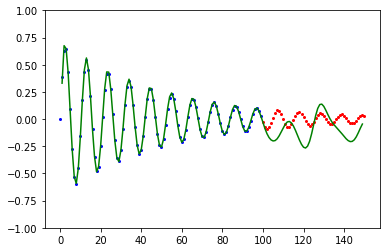

102800 3.4624606082563924e-05 0.22566811363822986


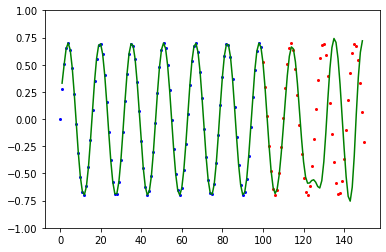

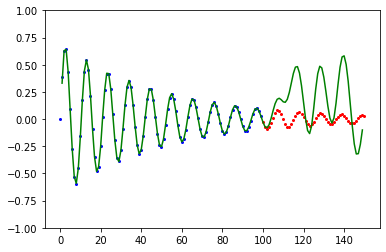

108900 3.408281189043261e-05 2.714539186605848


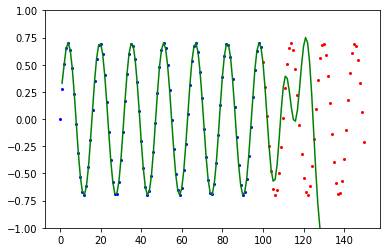

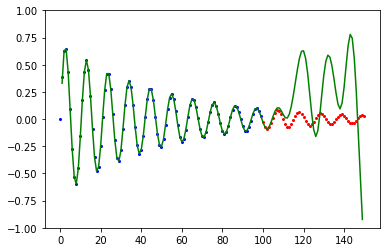

112700 3.4367620752523194e-05 0.6615953841016458


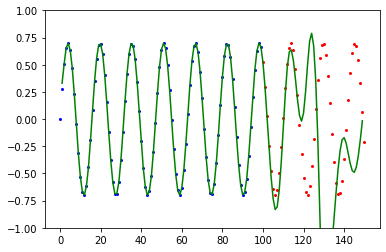

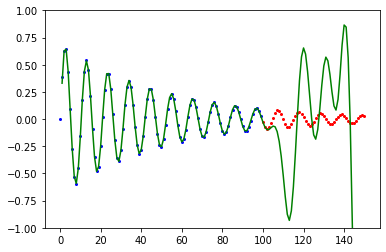

117400 4.9816274762363766e-05 0.21151026437504097


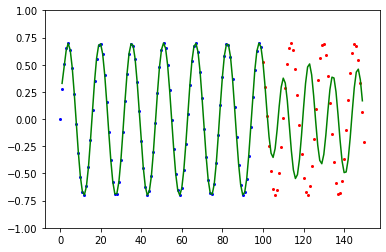

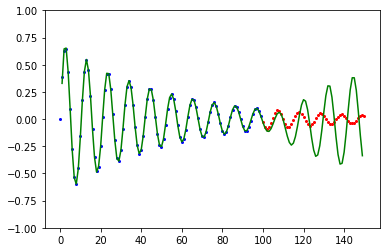

124000 5.502791741489879e-05 0.3137975222256759


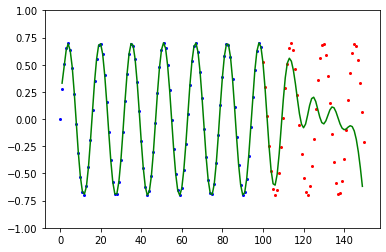

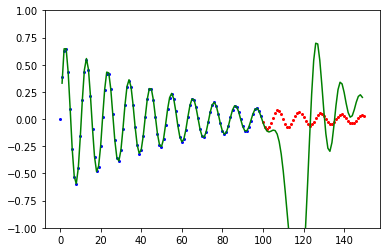

129900 3.429049717329952e-05 4.4036405898195605


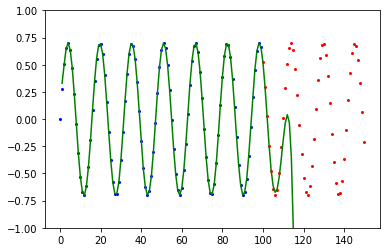

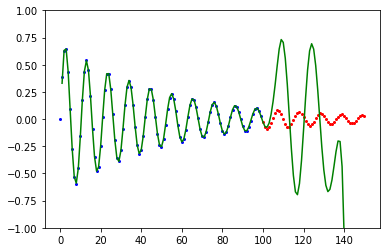

137100 3.354414743613704e-05 0.6882809175936737


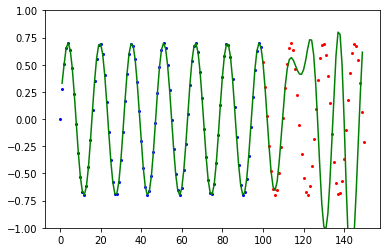

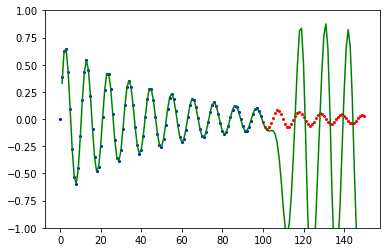

142300 4.459605433932243e-05 0.14462952126994008


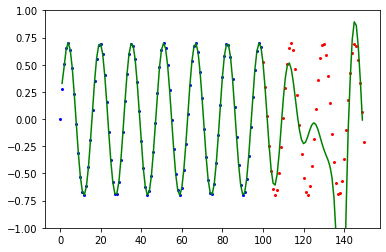

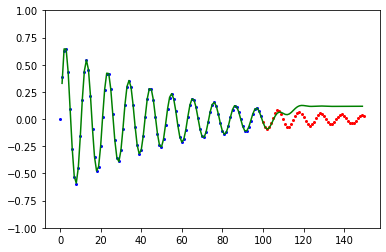

149300 3.566428899329401e-05 0.4910680543656443


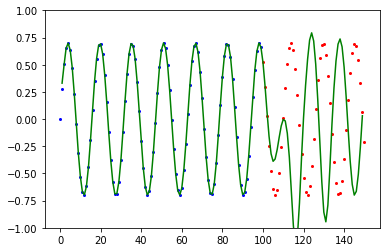

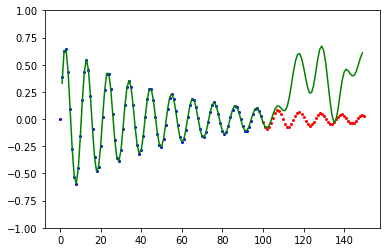

156700 5.80544924151218e-05 0.4590170556986247


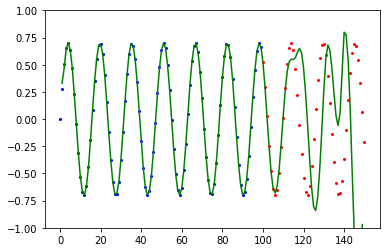

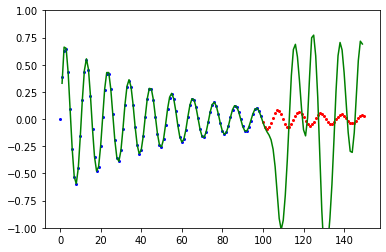

166300 3.402388913131139e-05 0.05244007708082252


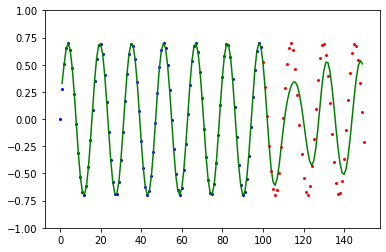

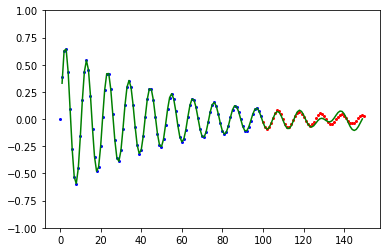

171600 3.5901347157330634e-05 0.709433022979372


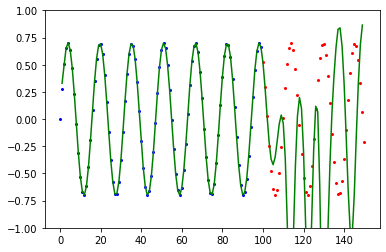

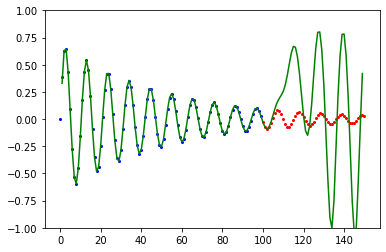

174800 3.321450995801284e-05 0.028371329725589815


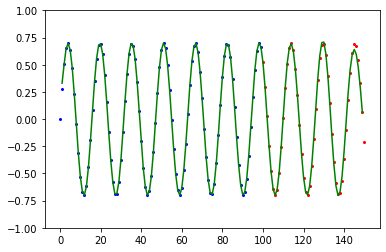

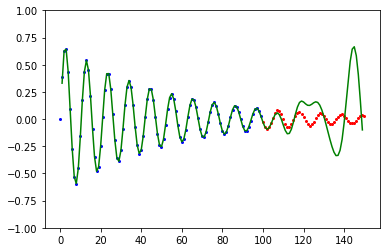

182500 3.334473724222323e-05 0.03427997584172123


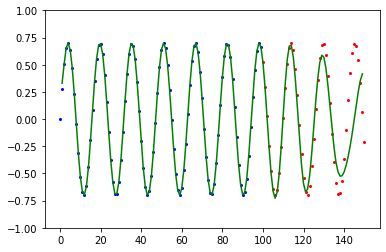

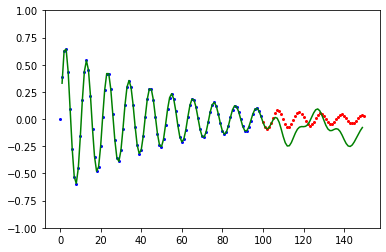

191100 3.384687876625734e-05 0.04602653527144557


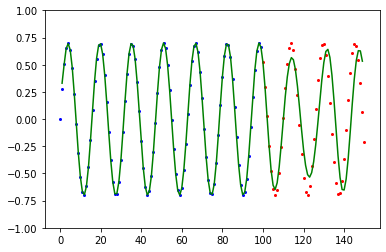

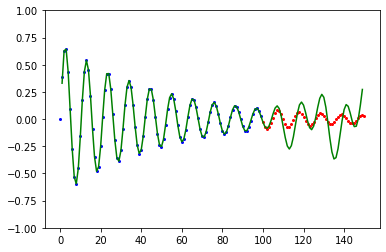

198100 4.627159273738515e-05 0.23839325096472003


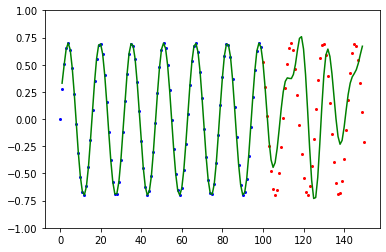

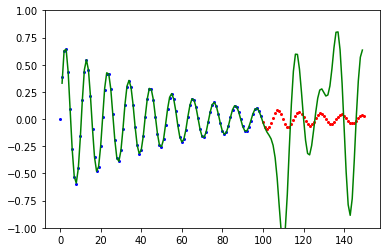

205100 3.5719695520444875e-05 0.30220098766643283


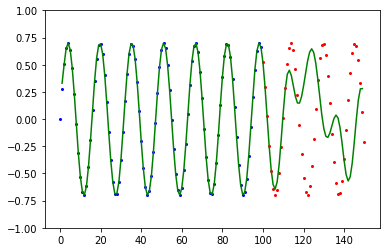

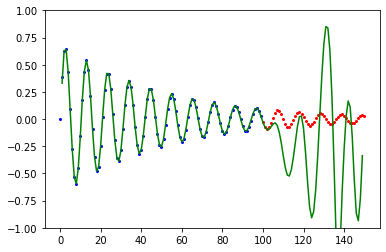

209700 3.3702631234192836e-05 0.03511074752820179


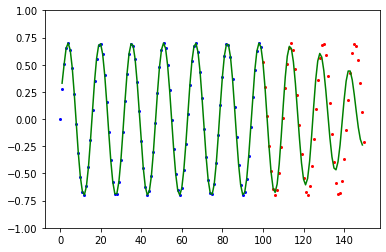

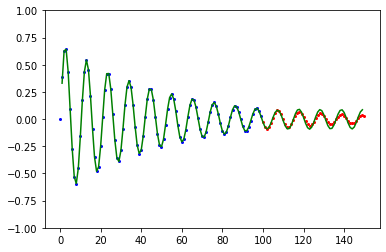

214900 3.4262416030320753e-05 0.041954164299848065


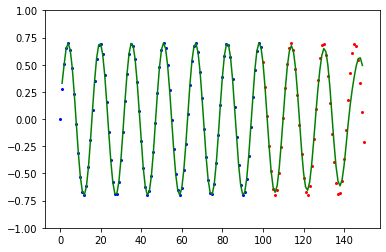

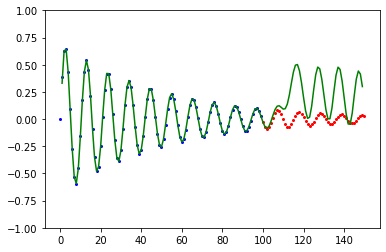

218800 3.6117580140947184e-05 0.42798285928437446


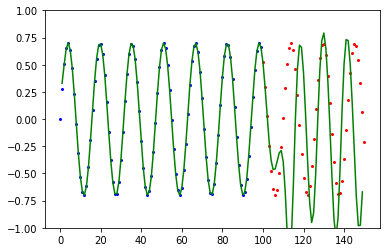

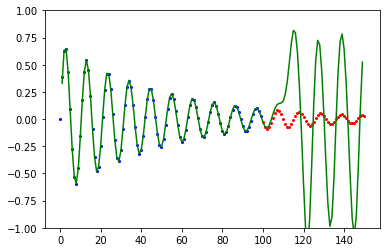

224400 4.297395078286792e-05 0.18694561440542515


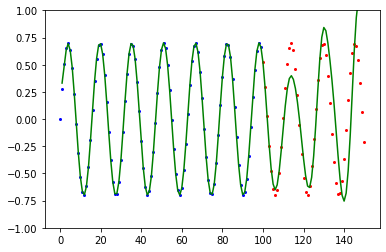

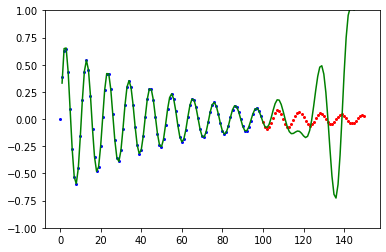

230900 3.4147769284488376e-05 0.08158175621268762


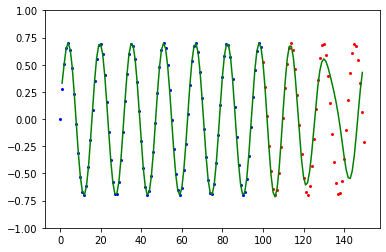

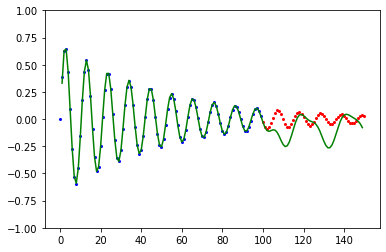

236800 3.367934576564541e-05 1.830652966770039


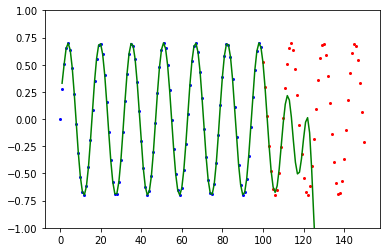

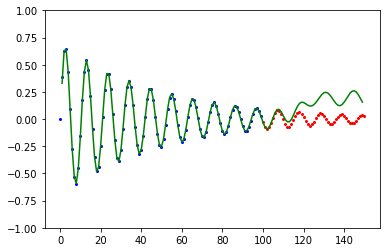

241800 3.667364900606948e-05 0.532209382373687


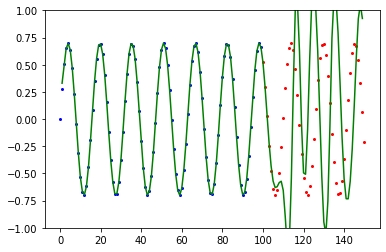

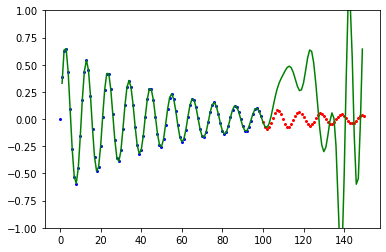

250700 3.339244791816243e-05 0.005715885196570815


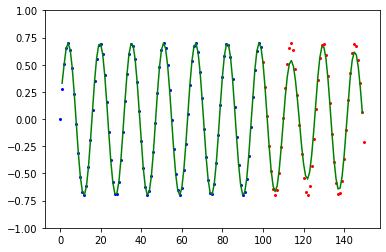

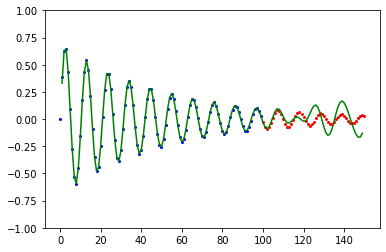

257700 5.758559925861875e-05 0.22139130623076295


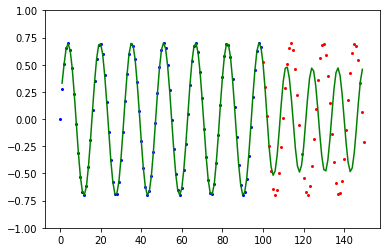

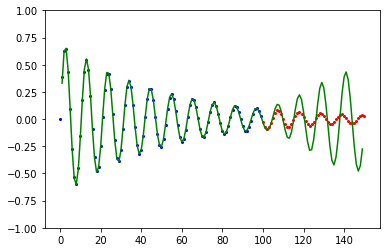

263800 3.36125834238699e-05 0.2920966781502656


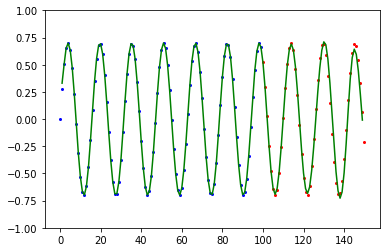

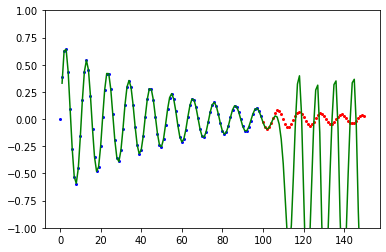

272100 3.344646362055346e-05 0.01743969285357046


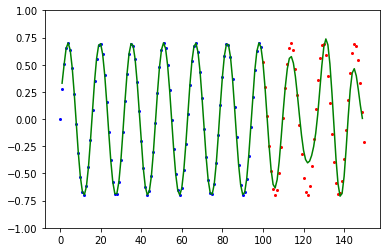

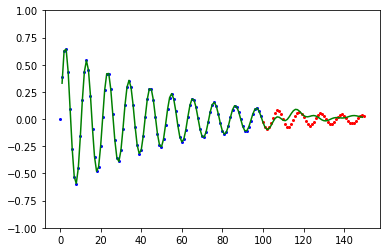

279500 6.0478288582970006e-05 2.01921459864867


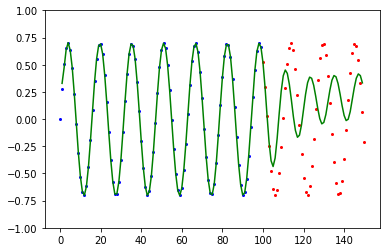

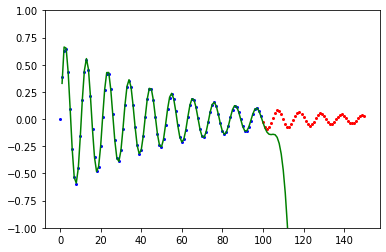

283900 3.4725772599364426e-05 0.5946613978973923


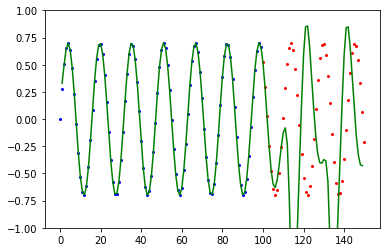

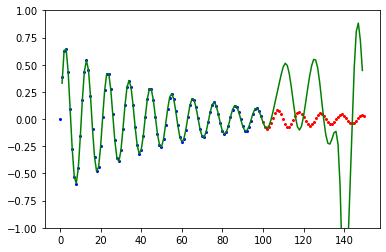

291000 6.0421742673289054e-05 0.10894012213631271


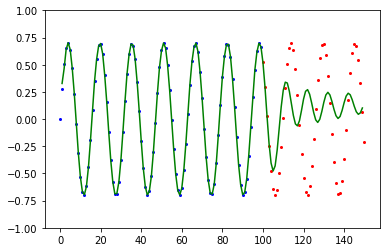

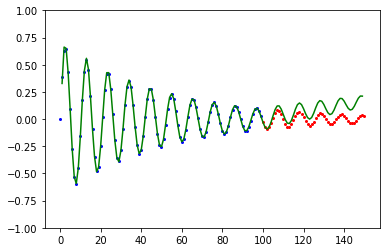

297800 3.337027982364318e-05 0.12145867453794224


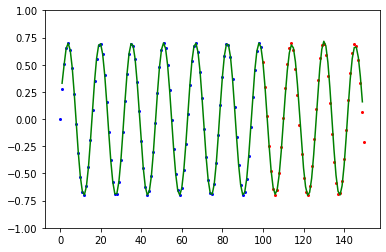

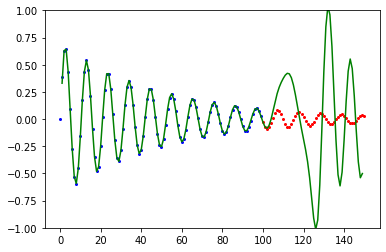

301900 3.4261828184988954e-05 0.20945824272865005


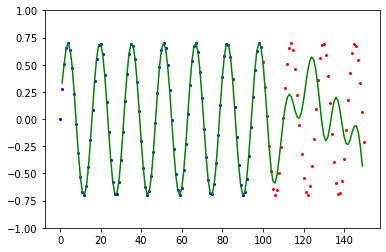

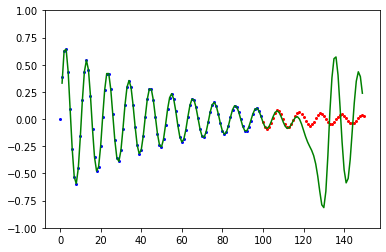

309800 3.437314544790977e-05 0.16066775609502731


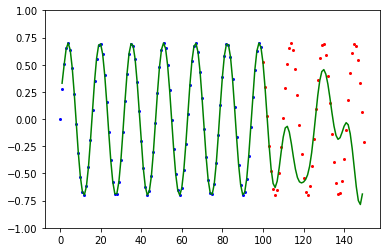

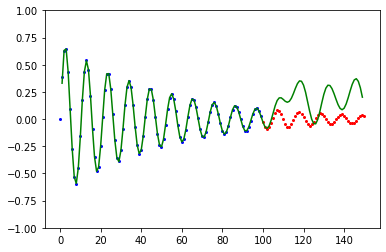

315800 3.318774799492383e-05 0.11653789138277527


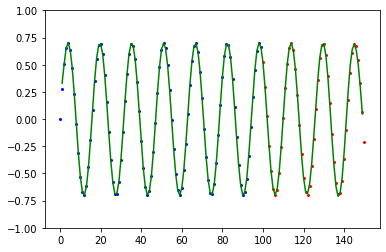

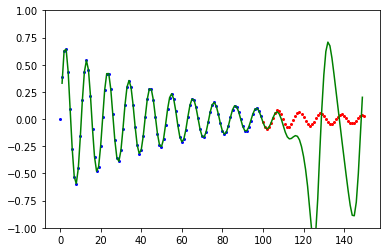

322100 3.4587768236839865e-05 0.6509774901572266


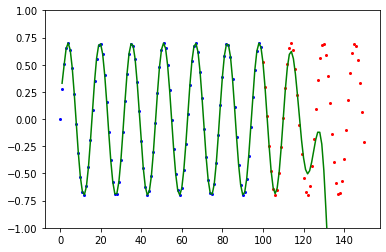

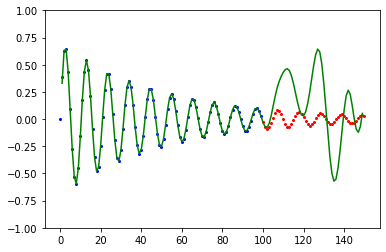

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.47732922, dtype=float64)

In [35]:
len(test_result)

50